# Graph Neural Network With NetworkX

NetworkX Documentation,

(https://networkx.org/documentation/stable/reference/index.html)

In [ ]:
import networkx as nx
import numpy as np

# Basics

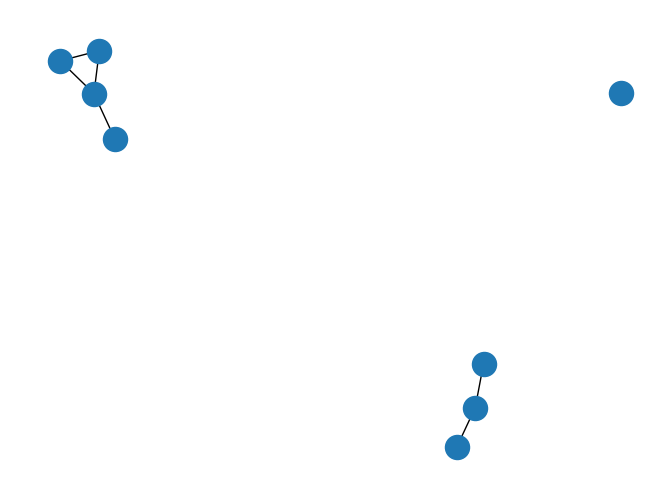

In [ ]:
# Creating a graph
G = nx.Graph()

# Adding nodes
G.add_node(1) # Adding single node
G.add_nodes_from([2, 3]) # Adding collection of nodes, here '[2, 3]' means adding 2 nodes and the location of all the nodes will be random
G.add_nodes_from([4, 5])
G.add_nodes_from([6, 7, 8])
G.add_nodes_from([9, 10])

# Removing nodes
G.remove_nodes_from([9, 10])

# Adding edges
G.add_edges_from([(1, 2), (2, 3), (3, 1)]) # Adding collection of edges
G.add_edge(5, 1) # Adding single edge
G.add_edges_from([(6, 7), (7, 8)])
G.add_edge(5, 3)

# Removing edges
G.remove_edge(5, 3)

# Showing the graph
nx.draw(G)

In [ ]:
# Number of nodes & edges
print("No. of nodes: ", G.number_of_nodes())
print("No. of edges: ", G.number_of_edges())

No. of nodes:  8
No. of edges:  6


In [ ]:
# Viewing nodes & edges
print("Nodes: ", G.nodes)
print("Edges: ", G.edges)

Nodes:  [1, 2, 3, 4, 5, 6, 7, 8]
Edges:  [(1, 2), (1, 3), (1, 5), (2, 3), (6, 7), (7, 8)]


In [ ]:
G.graph

{}

# Exporting Graph

Converting Graph to JSON Data

In [ ]:
from networkx.readwrite import json_graph
json_data = json_graph.node_link_data(G)
json_data

{'directed': False,
 'multigraph': False,
 'graph': {},
 'nodes': [{'id': 1},
  {'id': 2},
  {'id': 3},
  {'id': 4},
  {'id': 5},
  {'id': 6},
  {'id': 7},
  {'id': 8}],
 'edges': [{'source': 1, 'target': 2},
  {'source': 1, 'target': 3},
  {'source': 1, 'target': 5},
  {'source': 2, 'target': 3},
  {'source': 6, 'target': 7},
  {'source': 7, 'target': 8}]}

Converting JSON Data Back to Graph

In [ ]:
json_data_to_graph = json_graph.node_link_graph(json_data)
json_data_to_graph

In [ ]:
# Removing the existing graph
G.clear()

[(1, 2), (1, 3)]
[1, 2, 3]


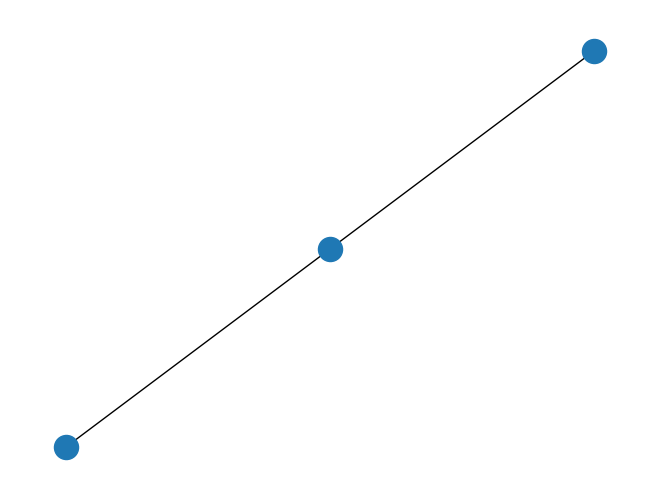

In [ ]:
# Adding edges without nodes creates nodes by itself
G.add_edges_from([(1, 2), (1, 3)])
print(G.edges)
print(G.nodes)
nx.draw(G)

[1, 2, 3, 'bar', 'b', 'a', 'r']
[(1, 2), (1, 3)]


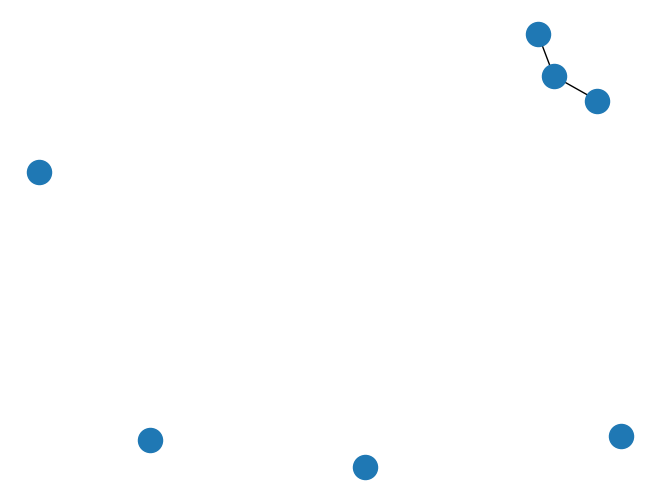

In [ ]:
G.add_node("bar") # Adds node 'bar'
G.add_nodes_from("bar") # Add nodes 'b', 'a', 'r'
print(G.nodes)
print(G.edges)
nx.draw(G)

In [ ]:
# Number of nodes
G.order()

7

Density of the graph

$Density~for~un-directed~graph$
<br><br>
$$d = \frac{2m}{n(n-1)}$$
<br><br>
$Density~for~directed~graph$
<br><br>
$$d = \frac{m}{n(n-1)}$$
<br><br>
$Where,~n~is~the~number~of~nodes~\&~and~m~is~the~number~of~edges~in~G.$


In [ ]:
from networkx.classes.function import density
density(G)

0.09523809523809523

Degree of the graph

In [ ]:
from networkx.classes.function import degree
degree(G, nbunch=None, weight=None) # Returns the degree of single node or nbunch nodes, if nbunch is omitted, then returns degrees of all the nodes.

DegreeView({1: 2, 2: 1, 3: 1, 'bar': 0, 'b': 0, 'a': 0, 'r': 0})

Degree histogram

In [ ]:
from networkx.classes.function import degree_histogram
degree_histogram(G) # Returns a list of frequency of each degree value. Output: [4, 2, 1] means '0' appears 4 times, '1' appears 2 times, '2' appears 1 time.

[4, 2, 1]

Neighboring nodes

In [ ]:
from networkx.classes.function import neighbors
neighbors(G, "bar") # The 'neighbors' function only returns the neighbors of node from which information flows to the other node in the directed graph.

In [ ]:
from networkx.classes.function import all_neighbors
all_neighbors(G, "bar") # The 'all_neighbors' function returns all the neighbors of the node 'bar' whether the information from it flows to some neighboring node or not.

In [ ]:
G.nodes

NodeView((1, 2, 3, 'bar', 'b', 'a', 'r'))

In [ ]:
for node in G.nodes:
  print(node, list(G.neighbors(node)))

1 [2, 3]
2 [1]
3 [1]
bar []
b []
a []
r []


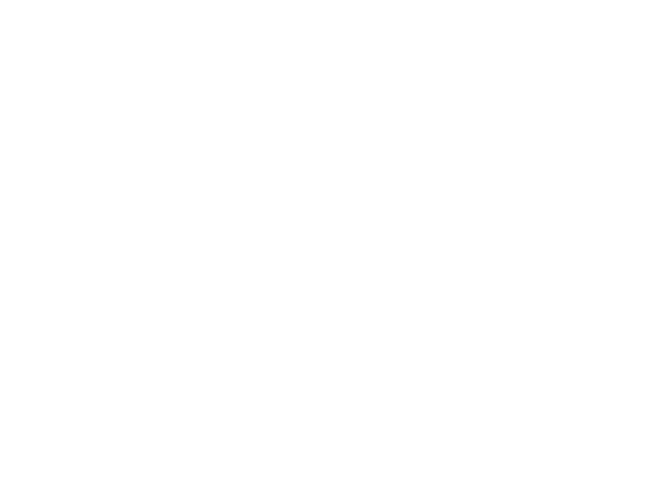

In [ ]:
G.clear()
nx.draw(G)

# Creating Path Graph

Path Graphs are the graphs in which nodes are linearly connected with each other.

False
False
False
False


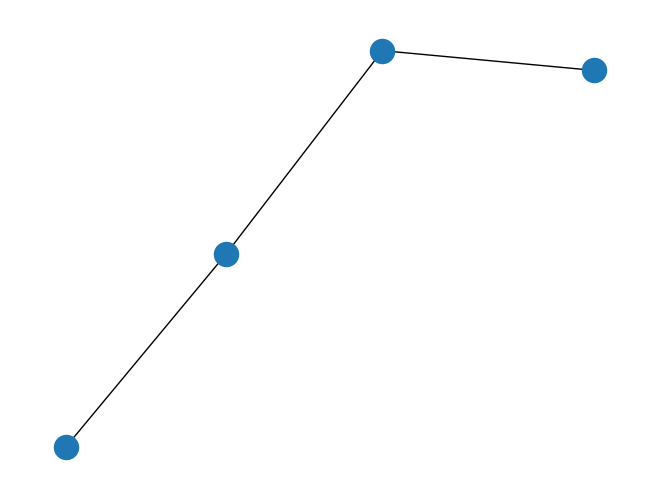

In [ ]:
G = nx.path_graph(4)
print(nx.is_weighted(G))
print(nx.is_weighted(G, (2, 3))) # Checking the edge connecting nodes 2 and 3 is weighted or not.
nx.draw(G)
print(nx.is_weighted(G))
print(nx.is_directed(G))

# Directional Graph

True
True


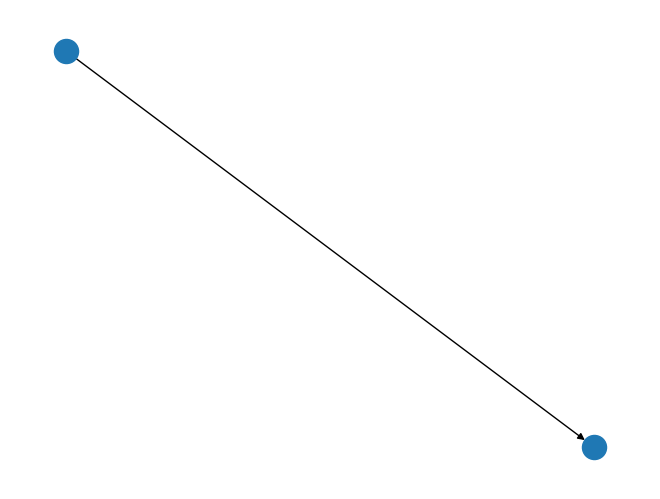

In [ ]:
G = nx.DiGraph()
G.add_edge(1, 2, weight = 1)
nx.draw(G)
print(nx.is_weighted(G))
print(nx.is_directed(G))

True
True


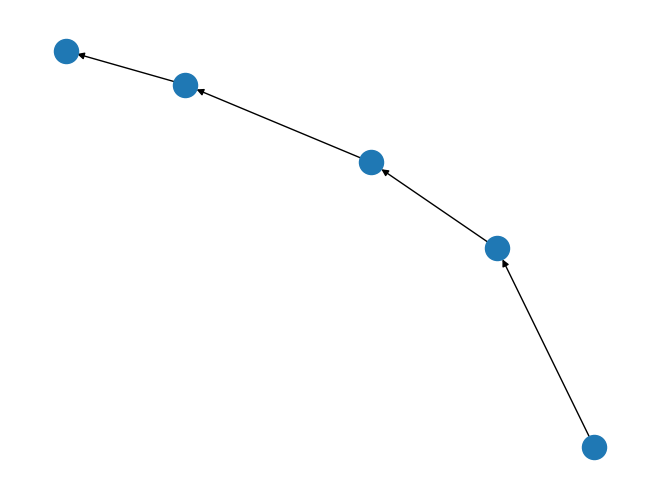

In [ ]:
G = nx.DiGraph()
G.add_edge(1, 2, weight = 1)
G.add_edge(2, 3, weight = 5)
G.add_edge(3, 4, weight = 3)
G.add_edge(4, 5, weight = 6)
nx.draw(G)
print(nx.is_weighted(G))
print(nx.is_directed(G))

# Neighbor & Adjacency

Is Weighted:  True
Is Directed:  True
No. of Nodes:  5
No. of Edges:  4
Edges:  [('a', 'b'), ('c', 'b'), ('d', 'b'), ('d', 'e')]
Nodes:  ['a', 'b', 'c', 'd', 'e']
'a' neighbors:  ['b']
'b' neighbors:  []
'b' all neighbors:  ['a', 'c', 'd']


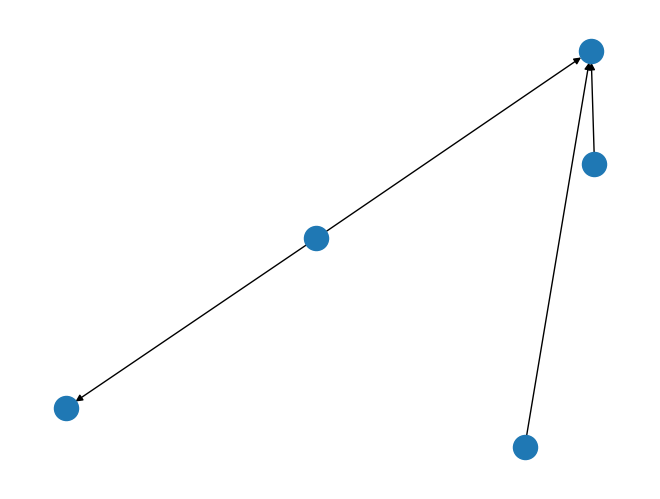

In [ ]:
G = nx.DiGraph()
G.add_edge("a", "b", weight = 1)
G.add_edge("c", "b", weight = 15)
G.add_edge("d", "b", weight = 25)
G.add_edge("d", "e", weight = 30)
nx.draw(G)
print("Is Weighted: ", nx.is_weighted(G))
print("Is Directed: ", nx.is_directed(G))
print("No. of Nodes: ", G.order())
print("No. of Edges: ", nx.number_of_edges(G))
print("Edges: ", G.edges())
print("Nodes: ", G.nodes())
print("'a' neighbors: ", [n for n in neighbors(G, "a")]) # 'neighbors' function only counts directed neighbors
print("'b' neighbors: ", [n for n in neighbors(G, "b")])
print("'b' all neighbors: ", [n for n in all_neighbors(G, "b")]) # 'all_neighbors' function counts all the neighbors whether directed or not.


In [ ]:
for x in G.nodes:
  print("\nNeighbors of " + x + ": ", [n for n in neighbors(G, x)])
  print("All Neighbors of " + x + ": ", [n for n in all_neighbors(G, x)])


Neighbors of a:  ['b']
All Neighbors of a:  ['b']

Neighbors of b:  []
All Neighbors of b:  ['a', 'c', 'd']

Neighbors of c:  ['b']
All Neighbors of c:  ['b']

Neighbors of d:  ['b', 'e']
All Neighbors of d:  ['b', 'e']

Neighbors of e:  []
All Neighbors of e:  ['d']


In [ ]:
sorted(all_neighbors(G, "b"))

['a', 'c', 'd']

# Adjacency Matrix

In [ ]:
A = nx.adjacency_matrix(G)
print(A.todense())

[[ 0  1  0  0  0]
 [ 0  0  0  0  0]
 [ 0 15  0  0  0]
 [ 0 25  0  0 30]
 [ 0  0  0  0  0]]


In [ ]:
A.diagonal() # Diagonal is showing '0s' because of absence of self looping

array([0, 0, 0, 0, 0])

In [ ]:
# Converting graph to numpy array
A = nx.to_numpy_array(G)
print(A)

[[ 0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0. 15.  0.  0.  0.]
 [ 0. 25.  0.  0. 30.]
 [ 0.  0.  0.  0.  0.]]


In [ ]:
# Setting the diagonal
np.fill_diagonal(A, A.diagonal() + 2)
print(A)

[[ 2.  1.  0.  0.  0.]
 [ 0.  2.  0.  0.  0.]
 [ 0. 15.  2.  0.  0.]
 [ 0. 25.  0.  2. 30.]
 [ 0.  0.  0.  0.  2.]]


# Multi-Directional Graph


[(0, 1, 0), (1, 0, 0), (2, 2, 0), (2, 2, 1)]
[0, 1, 2]


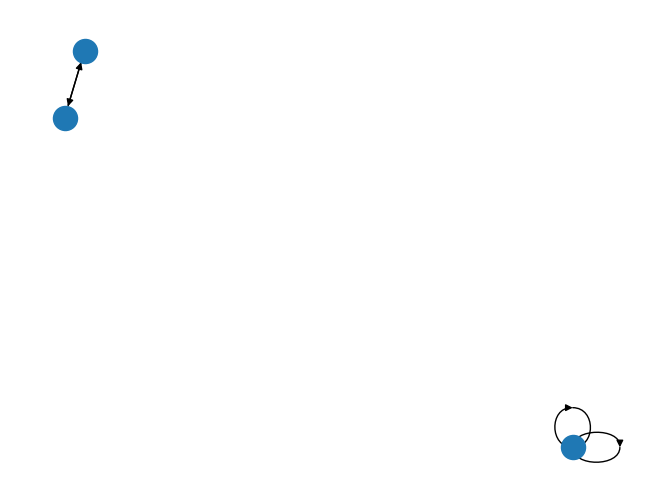

In [ ]:
G = nx.MultiDiGraph()
G.add_edge(0, 1, weight=2)
G.add_edge(1, 0)
G.add_edge(2, 2, weight=3)
G.add_edge(2, 2)
nx.draw(G)
print(G.edges)
print(G.nodes)


In [ ]:
A = nx.adjacency_matrix(G)
print(A.todense())

[[0 2 0]
 [1 0 0]
 [0 0 4]]


Setting non-edge values different than 0

[(3, 1), (3, 0), (1, 2), (2, 0)]
[3, 1, 2, 0]
[[0 2 0 1]
 [2 0 0 0]
 [0 0 0 0]
 [1 0 0 0]]
[[-1.  2. -1.  1.]
 [ 2. -1.  0. -1.]
 [-1.  0. -1.  0.]
 [ 1. -1.  0. -1.]]


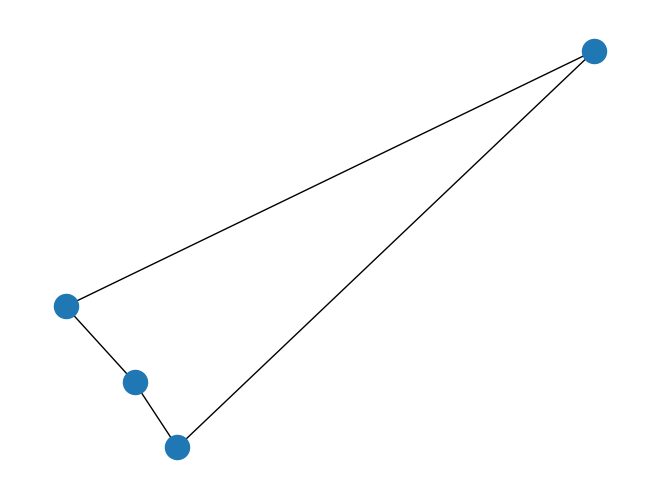

In [ ]:
G = nx.Graph()
G.add_edge(3, 1, weight=2)
G.add_edge(2, 0, weight=0)
G.add_edge(2, 1, weight=0)
G.add_edge(3, 0, weight=1)
nx.draw(G)
print(G.edges)
print(G.nodes)

# Ajacency matrix
A = nx.adjacency_matrix(G)
print(A.todense())

# Converted in numpy arrays form
print(nx.to_numpy_array(G, nonedge=-1.))

# Multiple Edge Attributes

Adjacency matrix of weight,
[[ 0 10  0  0]
 [10  0  1  0]
 [ 0  1  0  3]
 [ 0  0  3  0]]
Adjacency matrix of cost,
[[ 0.  1.  0.  0.]
 [ 1.  0.  5.  0.]
 [ 0.  5.  0. -4.]
 [ 0.  0. -4.  0.]]
[0, 1, 2, 3]
[(0, 1), (1, 2), (2, 3)]


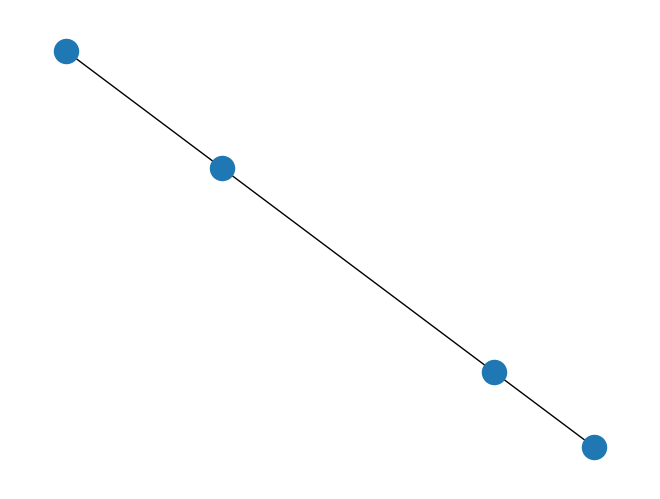

In [ ]:
G = nx.Graph()
G.add_edge(0, 1, weight=10)
G.add_edge(1, 2, cost=5)
G.add_edge(2, 3, weight=3, cost=-4.0)
dtype = np.dtype([("weight", int), ("cost", float)])
A = nx.to_numpy_array(G, dtype=dtype, weight=None)
print("Adjacency matrix of weight,")
print(A["weight"])
print("Adjacency matrix of cost,")
print(A["cost"])
nx.draw(G)
print(G.nodes)
print(G.edges)

Returning adjacency representation of graph as a dictionary of dictionaries

[0, 1, 2]
[(0, 1), (0, 2), (1, 2)]
---------------
{0: {1: {'weight': 1.0}, 2: {'weight': 1.0}}, 1: {0: {'weight': 1.0}, 2: {'weight': 2.0}}, 2: {1: {'weight': 2.0}, 0: {'weight': 1.0}}}
2.0


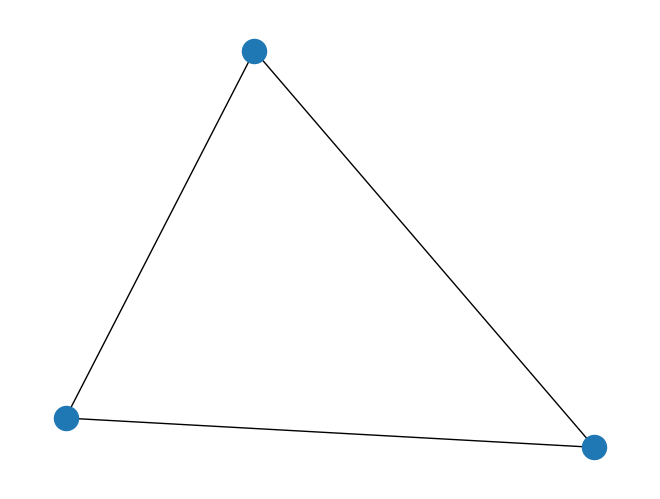

In [ ]:
G = nx.Graph()
G.add_edges_from(
    [
        (0, 1, {"weight": 1.0}),
        (1, 2, {"weight": 2.0}),
        (2, 0, {"weight": 1.0}),
    ]
)
nx.draw(G)
print(G.nodes)
print(G.edges)
print("---------------")
d = nx.to_dict_of_dicts(G)
print(d) # The output say, '{0: {1: {'weight': 1.0}, 2: {'weight': 1.0}}' the outer key '0' is the node and the inner keys are the neighboring nodes to which the '0th' is node attached along with their corresponding weights.
print(d[1][2]["weight"]) # d[node][neighboring_node][attribute]

In multi-directiona graph

[0, 1]
[(0, 1, 'a'), (0, 1, 'b')]
-------------
{0: {1: {'a': {'weight': 1.0}, 'b': {'weight': 3.0}}}, 1: {0: {'a': {'weight': 1.0}, 'b': {'weight': 3.0}}}}
3.0


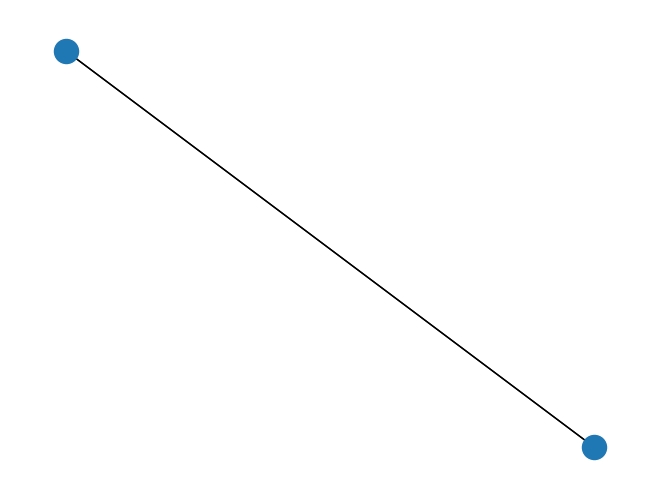

In [ ]:
G = nx.MultiGraph()
G.add_edge(0, 1, key = "a", weight = 1.0)
G.add_edge(0, 1, key = "b", weight = 3.0)
nx.draw(G)
print(G.nodes)
print(G.edges)
print("-------------")
d = nx.to_dict_of_dicts(G)
print(d)
print(d[0][1]["b"]["weight"])

Showing data in Pandas dataframe

['A', 'B', 'C', 'D']
[('A', 'B'), ('C', 'D')]
---------------------
  source target  cost  weight
0      A      B     1       4
1      C      D     6       8
--------------------
  source target  cost  weight
0      A      B     1       4
1      C      D     6       8
--------------------
  source target  cost  weight
0      A      B     1       4
1      D      C     6       8
--------------------
The adjacency matrix is,
 [[0 4 0 0]
 [4 0 0 0]
 [0 0 0 8]
 [0 0 8 0]]


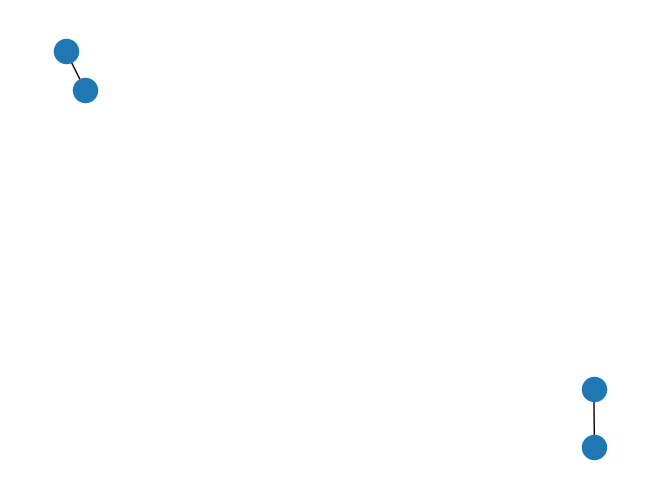

In [ ]:
G = nx.Graph(
    [
        ("A", "B", {"cost": 1, "weight": 4}),
        ("C", "D", {"cost": 6, "weight": 8}),
    ]
)
nx.draw(G)
print(G.nodes)
print(G.edges)
print("---------------------")
df = nx.to_pandas_edgelist(G)
print(df)
print("--------------------")
df = nx.to_pandas_edgelist(G, nodelist=["A", "C"])
print(df)
print("--------------------")
df = nx.to_pandas_edgelist(G, nodelist=["A", "D"])
print(df)
print("--------------------")
df[["source", "target", "cost", "weight"]]

A = nx.adjacency_matrix(G)
print("The adjacency matrix is,\n", A.todense())

In multi-graph

['A', 'B']
[('A', 'B', 0), ('A', 'B', 1)]
  source target  ekey  cost
0      A      B     0     1
1      A      B     1     8
---------------------
  source target  cost  ekey
0      A      B     1     0
1      A      B     8     1
-----------------------
  source target  ekey  cost
0      A      B     0     1
1      A      B     1     8
-----------------------
  source target  cost  ekey
0      A      B     1     0
1      A      B     8     1
The adjacency matrix is,
 [[0 2]
 [2 0]]


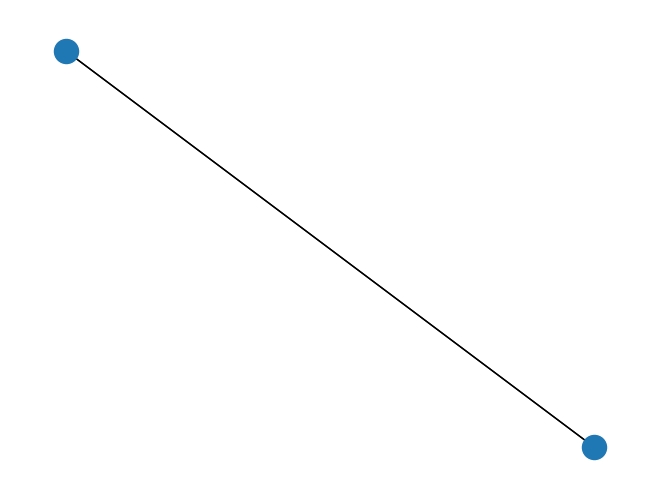

In [ ]:
G = nx.MultiGraph(
    [
        ("A", "B", {"cost": 1}),
        ("A", "B", {"cost": 8}),
    ]
)
nx.draw(G)
print(G.nodes)
print(G.edges)
df = nx.to_pandas_edgelist(G, nodelist=["A", "B"], edge_key="ekey")
print(df)
print("---------------------")
print(df[["source", "target", "cost", "ekey"]])
print("-----------------------")
df = nx.to_pandas_edgelist(G, nodelist=["A", "B"], edge_key="ekey")
print(df)
print("-----------------------")
print(df[["source", "target", "cost", "ekey"]])

A = nx.adjacency_matrix(G)
print("The adjacency matrix is,\n", A.todense())

# Sudoku Graph

81
810
-------------------
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]


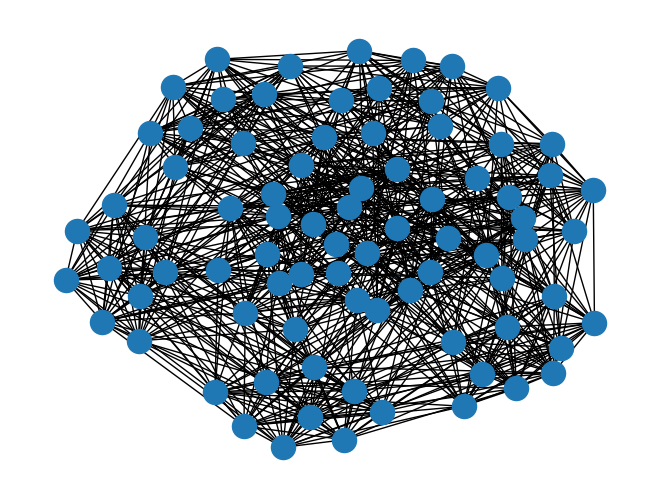

In [ ]:
# Default is 3x3 = 9 nodes
G = nx.sudoku_graph()
print(G.number_of_nodes())
print(G.number_of_edges())
print("-------------------")
A = nx.adjacency_matrix(G)
print(A.todense())
nx.draw(G)

In [ ]:
print("Is Multi_graph: ", G.is_multigraph())
print("Is Directed graph: ", G.is_directed())

Is Multi_graph:  False
Is Directed graph:  False


# Grid Graph

[[0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 1 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0

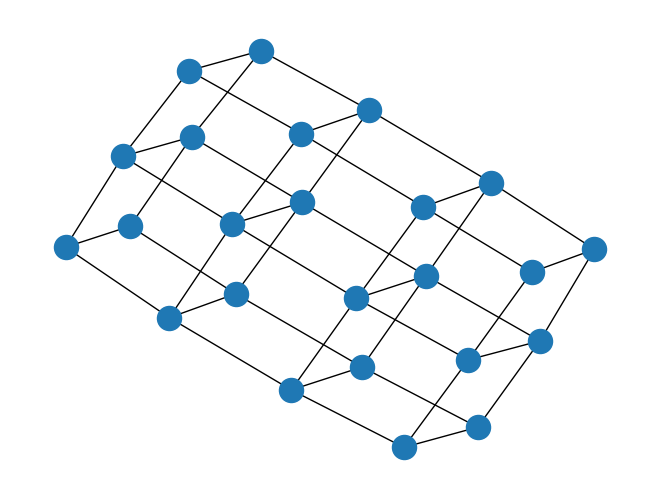

In [ ]:
G = nx.grid_graph(dim=(2,3, 4))
# G = nx.grid_graph([4,4]) # We can also write in this way.
nx.draw(G)
A = nx.adjacency_matrix(G)
print(A.todense())
